In [8]:

#Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [14]:
## Decisons
class Config:
    def __init__(self):
        #C:\Users\Miles\Documents\morris research\computing\All ress\DFT D3-BJ\low energy files\DFT-D3-BJ_all_structures_summary.csv
        #"C:\Users\Miles\Documents\morris research\computing\All ress\DFT D3\low energy files\DFT-D3_all_structures_summary.csv"
        self.file_path = Path(r"C:\Users\Miles\Documents\morris research\computing\All ress\DFT D3\low energy files\DFT-D3_all_structures_summary.csv") ## This is the path to the CSV file. Change this to the path of your CSV file.
        self.plot_leading_edge = False ## Set to True if you want to plot the leading edge of the data.
        self.fu_to_color = {
                    1: 'red', 2: 'green', 3: 'blue',
                    4: 'purple', 6: 'magenta', 8: 'cyan',
                    'other': 'black'
                }    ## Change the colours per formula unit 
        self.filterd_out_colour = 'grey' ## Change the colour of the filtered out points
        self.filterd_out_marker_size = 30 ## Change the size of the filtered out points
        self.origin_to_marker = {
            'AIRSS': 'o', 'Swap': '^' , 'Experimental': '*', 'AIRSS/Swap':'D'
        }    ## Change the markers per origin

        self.Expereimtal_marker_size= 200 ## Change the size of the experimental marker
        self.Expereimtal_marker_color= 'gold' ## Change the color of the experimental marker#

        ## now for the filters and if you want to hide stuff
        self.filter_out_cyanurates = False ## Set to True if you want to filter out cyanurate structures.
        self.hide_cyanurate = False ## Set to True if you want to hide the cyanurate structures.
        self.filter_for_InN6_InS6_structure = False ## Set to True if you want to filter out InN6 and InS6 structures.
        self.hide_non_InN6_InS6_structures = False ## Set to True if you want to hide the filtered out points.
        self.filter_for_octahedral_indium = False ## Set to True if you want to filter out non-octahedral indium structures.
        self.hide_non_octahedral_indium = False ## Set to True if you want to hide the filtered out points.

        self.filter_non_low_energy_files= False
        self.hide_non_low_energy_files= False
        self.low_energy_plot= False

        


In [10]:
def Create_convex_hull(config ,densities: np.ndarray, energies: np.ndarray):
    """Create the lower leading-edge envelope, tethered to the graph edges.

    The boundary should run from the left edge to the right edge without looping
    back on itself. To enforce that, we add explicit edge anchors and then build
    the monotone lower hull from left to right using the real data only.
    """
    densities = np.asarray(densities, dtype=float)
    energies = np.asarray(energies, dtype=float)

    valid = np.isfinite(densities) & np.isfinite(energies)
    densities = densities[valid]
    energies = energies[valid]

    if densities.size == 0:
        return np.array([], dtype=float), np.array([], dtype=float)
    if densities.size == 1:
        return np.array([energies[0], energies[0]], dtype=float), np.array([densities[0], densities[0]], dtype=float)

    x_min = densities.min()
    x_max = densities.max()
    y_max = energies.max()
    pad_x = max(0.05, 0.05 * (x_max - x_min)) if x_max > x_min else 0.05
    pad_y = max(10.0, 0.05 * abs(y_max))
    if config.low_energy_plot:
        left_anchor = np.array([0.579, 120], dtype=float)
        right_anchor = np.array([2.504, 120], dtype=float)
    else:
        left_anchor = np.array([x_min - pad_x, y_max + pad_y], dtype=float)
        right_anchor = np.array([x_max + pad_x, y_max + pad_y], dtype=float)

    unique_densities = np.unique(densities)
    min_energies = np.array([
        energies[densities == density].min() for density in unique_densities
    ], dtype=float)
    points = np.column_stack((unique_densities, min_energies))
    points = np.vstack([points, left_anchor, right_anchor])

    ordered = points[np.lexsort((points[:, 1], points[:, 0]))]
    lower = []
    for point in ordered:
        while len(lower) >= 2:
            a = lower[-2]
            b = lower[-1]
            cross = (b[0] - a[0]) * (point[1] - a[1]) - (b[1] - a[1]) * (point[0] - a[0])
            if cross <= 0:
                lower.pop()
            else:
                break
        lower.append(point)

    lower = np.asarray(lower, dtype=float)
    lower = lower[np.argsort(lower[:, 0])]

    x_dense = np.linspace(lower[:, 0].min(), lower[:, 0].max(), max(200, len(lower) * 10))
    y_dense = np.interp(x_dense, lower[:, 0], lower[:, 1])
    return y_dense, x_dense


def main(df, config: Config=None ):
    file_name= df['file_name']
    origin_of_structure = df['origin_of_structure']
    energy_per_atom = df['energy_per_atom']
    densities = np.array(df['density'])
    formula_units = df['formula_units']
    stoichiometry = df['stoichiometry']
    has_cyanurate_structure = df['has_cyanurate_structure']
    has_octahedral_indium = df['has_octahedral_indium']
    has_InN6_InS6_structure = df['has_InN6_InS6_structure']
    in_low_energy_folder = df['in_low_energy_folder']
    filtered_out= np.array(len(densities)* [False], dtype=bool) ## this is a boolean array that will be used to filter out points from the plot. It is set to False for all points by default.
    hidden_structures= np.array(len(densities)* [False], dtype=bool) ## this is a boolean array that will be used to hide points from the plot. It is set to False for all points by default.



    filtered_out = (config.filter_out_cyanurates & has_cyanurate_structure )| \
                    (config.filter_for_InN6_InS6_structure & ~has_InN6_InS6_structure) | \
                    (config.filter_for_octahedral_indium & ~has_octahedral_indium)|\
                    (config.filter_non_low_energy_files & ~ in_low_energy_folder)

    hidden_structures = (config.hide_cyanurate & has_cyanurate_structure) | \
                        (config.hide_non_InN6_InS6_structures & ~has_InN6_InS6_structure) | \
                        (config.hide_non_octahedral_indium & ~has_octahedral_indium) |\
                        (config.hide_non_low_energy_files & ~in_low_energy_folder)
    energies= energy_per_atom - min(energy_per_atom[~hidden_structures]) ## this makes all the energies relative to the lowest energy structure
    print (f"Number of hidden structures: {np.sum(hidden_structures)}")
    fig,ax = plt.subplots(figsize=(10, 6))
    plt.subplots_adjust(right=0.75)
    if config.plot_leading_edge:
        leading_energies, leading_densities = Create_convex_hull(config, densities[~hidden_structures], energies[~hidden_structures])
        ax.plot(leading_densities, leading_energies, color='k', label='Leading Edge', linestyle='--', zorder= 10) ## can change the colour of the leading edge line here
        ax.plot(leading_densities, leading_energies +30 , 'r', label='Leading edge + 30meV/atom ',linestyle='--' ,zorder= 10)
        ax.hlines(y= 100 , xmin= 0 ,xmax= 4, label= '100meV/atom threshold' , linestyles='--' , color='grey', zorder = 9  )


    fu_labels = np.array([
        fu if fu in config.fu_to_color else 'other' 
        for fu in formula_units
    ])
    group_keys = np.array([f"{o}_{fu}_{filtered_out}_{hidden}" for o, fu, filtered_out, hidden in zip(origin_of_structure, fu_labels, filtered_out, hidden_structures)])
    unique_groups = np.unique(group_keys)

    grouped = {}
    for group in unique_groups:
        mask = group_keys == group
        indices = np.where(mask)[0]
        origin, fu_label, filtered_out, hidden = group.rsplit('_', 3)
        grouped[(origin, fu_label, filtered_out, hidden)] = indices


    scatter_points = []
    for (origin, fu_label, filtered_out, hidden), idxs in grouped.items():

        if hidden== 'True' :
            continue

        marker = config.origin_to_marker[origin]
        if filtered_out == 'True':
            colour = config.filterd_out_colour
        else:
            try:
                fu_int = int(fu_label)
                colour = config.fu_to_color.get(fu_int, config.fu_to_color['other'])
            except ValueError:
                colour = config.fu_to_color['other']

       ## the defalt size and shape of the markers
        size = 60
        zorder=5
        alpha= 0.8
        width= 0.5
        filtered="not filtered"
        
        if filtered_out == 'True':
            ## filterd out makrse style
            size =config.filterd_out_marker_size
            zorder= 1
            alpha = 0.5
            width= 0.5
            filtered= "filtered"
        elif origin == 'Experimental':
            # expereimental marker style
            size = config.Expereimtal_marker_size
            zorder= 10
            alpha= 1
            colour= config.Expereimtal_marker_color
            width= 1
        ## if you wanted to add different styles for different origins just add an if statement here
        sc = ax.scatter(
            densities[idxs], energies[idxs],
            marker=marker, color=colour, alpha=alpha,
            label=f"{origin} | {fu_label} FU | {filtered}" , s=size ,edgecolors='black',linewidth= width, zorder=zorder
        )
        scatter_points.append((sc, idxs))

    if config.low_energy_plot:
        ax.set_xlim(left=0.5, right=2.6 )  # Ensure x-axis starts at 0
        ax.set_ylim(top = 110,bottom=-5)  # Ensure y-axis starts just below 0 
    else:
        x_min = densities[~hidden_structures].min()
        x_max = densities[~hidden_structures].max()
        pad_x = max(0.05, 0.05 * (x_max - x_min)) if x_max > x_min else 0.05
        ax.set_ylim( top= max(energies[~hidden_structures])+ 30)
        ax.set_xlim(left= x_min - pad_x , right= x_max + pad_x)
    ax.set_xlabel('Density (g/cm³)', fontsize=14)
    ax.set_ylabel('Relative Energy (meV/atom)', fontsize=14)    
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.grid(True, alpha=0.3)
    ax.legend(
        by_label.values(), by_label.keys(),
        loc='upper left', bbox_to_anchor=(1.05, 1),
        title="Stoichiometry | F.U."
    )
    plt.show()



Number of hidden structures: 0


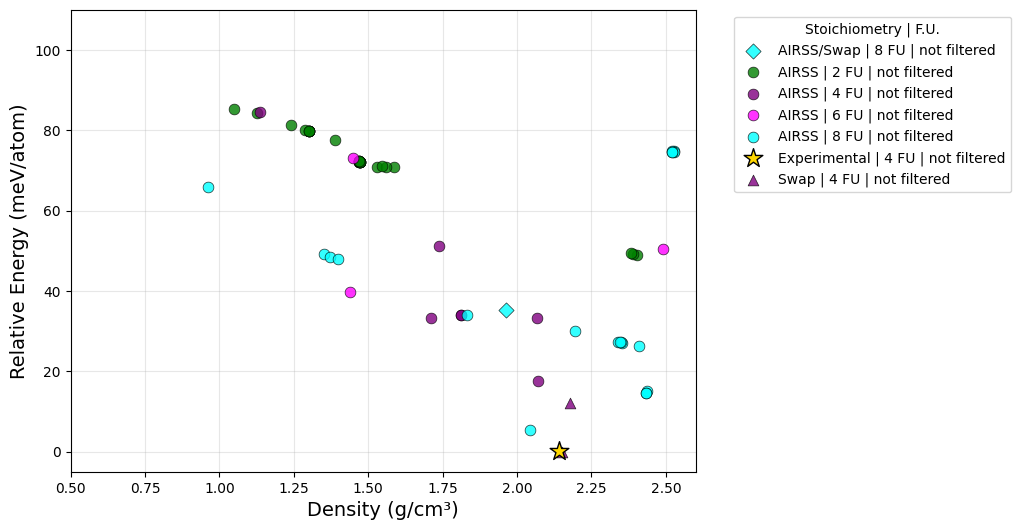

In [16]:

config=Config()
config.filter_out_cyanurates = False ## Set to True if you want to filter out cyanurate structures.
config.hide_cyanurate = True ## Set to True if you want to hide the cyanurate structures.
config.filter_for_InN6_InS6_structure = False ## Set to True if you want to filter out InN6 and InS6 structures.
config.hide_non_InN6_InS6_structures = False ## Set to True if you want to hide the filtered out points.
config.filter_for_octahedral_indium = False ## Set to True if you want to filter out non-octahedral indium structures.
config.hide_non_octahedral_indium = False ## Set to True if you want to hide the filtered out points.

config.filter_non_low_energy_files= False
config.hide_non_low_energy_files= False
config.plot_leading_edge= False
config.low_energy_plot= True
df = pd.read_csv(config.file_path, comment='#')

main(df, config)
